In [45]:
import copy
import json
import os
import re
import time
import warnings

In [46]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler

In [48]:
SEED = 42
DATA_DIR = os.environ.get("ML1M_DIR", "data")
ART_DIR = "artifacts"
SHRINK_K = 5
N_SVD = 20
NN_EPOCHS = 30
NN_BATCH = 4096
NN_PATIENCE = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(ART_DIR, exist_ok=True)
np.random.seed(SEED)
torch.manual_seed(SEED)

OCCUPATIONS = {0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin", 4: "college/grad student",
               5: "customer service", 6: "doctor/health care", 7: "executive/managerial", 8: "farmer",
               9: "homemaker", 10: "K-12 student", 11: "lawyer", 12: "programmer", 13: "retired",
               14: "sales/marketing", 15: "scientist", 16: "self-employed", 17: "technician/engineer",
               18: "tradesman/craftsman", 19: "unemployed", 20: "writer"}
AGE_GROUPS = {1: "Under 18", 18: "18-24", 25: "25-34", 35: "35-44", 45: "45-49", 50: "50-55", 56: "56+"}
KNOWN_GENRES = ["Action", "Adventure", "Animation", "Children's", "Comedy", "Crime", "Documentary", "Drama",
                "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller",
                "War", "Western"]

In [49]:
def find_dataset_dir():
    for dp, _, files in os.walk(DATA_DIR):
        if {"movies.dat", "users.dat", "ratings.dat"} <= set(files):
            return dp

    raise FileNotFoundError(
        f"Could not find movies.dat, users.dat, and ratings.dat under '{DATA_DIR}'. "
        "Place all three .dat files in that folder or a subfolder, "
        "or set ML1M_DIR to their parent directory."
    )

In [50]:
d = find_dataset_dir()
print(f"Dataset folder: {d}")
# The .dat files use the multi-character separator '::' and are latin-1 encoded (accented movie titles).
ratings = pd.read_csv(f"{d}/ratings.dat", sep="::", engine="python", encoding="latin-1",
                      names=["UserID", "MovieID", "Rating", "Timestamp"])
users = pd.read_csv(f"{d}/users.dat", sep="::", engine="python", encoding="latin-1",
                    names=["UserID", "Gender", "Age", "Occupation", "Zip"])
movies = pd.read_csv(f"{d}/movies.dat", sep="::", engine="python", encoding="latin-1",
                     names=["MovieID", "Title", "Genres"])

Dataset folder: data


In [51]:
for name, df in [("ratings", ratings), ("users", users), ("movies", movies)]:
    print(f"\n--- {name}: shape={df.shape}")
    print(df.head(3).to_string())
    print(df.dtypes.to_string())
print("\nRatings summary:\n", ratings[["Rating", "Timestamp"]].describe().to_string())



--- ratings: shape=(1000209, 4)
   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64

--- users: shape=(6040, 5)
   UserID Gender  Age  Occupation    Zip
0       1      F    1          10  48067
1       2      M   56          16  70072
2       3      M   25          15  55117
UserID        int64
Gender          str
Age           int64
Occupation    int64
Zip             str

--- movies: shape=(3883, 3)
   MovieID                    Title                        Genres
0        1         Toy Story (1995)   Animation|Children's|Comedy
1        2           Jumanji (1995)  Adventure|Children's|Fantasy
2        3  Grumpier Old Men (1995)                Comedy|Romance
MovieID    int64
Title        str
Genres       str

Ratings summary:
              Rating     Timestamp
count  1.000209e+06  1.000209e+06
mean   3.581564e

In [52]:
n_u, n_m, n_r = ratings.UserID.nunique(), ratings.MovieID.nunique(), len(ratings)
sparsity = 1 - n_r / (n_u * n_m)
print(f"\nUsers with ratings: {n_u} | Movies with ratings: {n_m} (of {len(movies)} in movies.dat) | Ratings: {n_r}")
print(f"Interaction-matrix sparsity: {sparsity:.2%}")


Users with ratings: 6040 | Movies with ratings: 3706 (of 3883 in movies.dat) | Ratings: 1000209
Interaction-matrix sparsity: 95.53%


In [53]:
rating_dist = ratings.Rating.value_counts(normalize=True).sort_index()
print("\nRating distribution:\n", rating_dist.round(3).to_string())
print(f"Mean rating = {ratings.Rating.mean():.3f}, std = {ratings.Rating.std():.3f}.")


Rating distribution:
 Rating
1    0.056
2    0.108
3    0.261
4    0.349
5    0.226
Mean rating = 3.582, std = 1.117.


In [54]:
per_user = ratings.groupby("UserID").size()
per_movie = ratings.groupby("MovieID").size()
print(f"\nRatings per user : min={per_user.min()}, median={per_user.median():.0f}, mean={per_user.mean():.1f}, max={per_user.max()}")
print(f"Ratings per movie: min={per_movie.min()}, median={per_movie.median():.0f}, mean={per_movie.mean():.1f}, max={per_movie.max()}")


Ratings per user : min=20, median=96, mean=165.6, max=2314
Ratings per movie: min=1, median=124, mean=269.9, max=3428


In [55]:
genre_counts = movies.Genres.str.split("|").explode().value_counts()
print("\nGenre counts:\n", genre_counts.to_string())
print(f"Gender split of users: {users.Gender.value_counts(normalize=True).round(3).to_dict()}")
print(f"Age buckets: {users.Age.map(AGE_GROUPS).value_counts().to_dict()}")


Genre counts:
 Genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Gender split of users: {'M': 0.717, 'F': 0.283}
Age buckets: {'25-34': 2096, '35-44': 1193, '18-24': 1103, '45-49': 550, '50-55': 496, '56+': 380, 'Under 18': 222}


In [56]:
full = ratings.merge(users, on="UserID").merge(movies, on="MovieID")
print("\nMean rating by gender:\n", full.groupby("Gender").Rating.mean().round(3).to_string())
print("\nMean rating by age group:\n", full.groupby("Age").Rating.mean().rename(index=AGE_GROUPS).round(3).to_string())


Mean rating by gender:
 Gender
F    3.620
M    3.569

Mean rating by age group:
 Age
Under 18    3.550
18-24       3.508
25-34       3.545
35-44       3.618
45-49       3.638
50-55       3.715
56+         3.767


In [57]:
genre_mean = (full.assign(G=full.Genres.str.split("|")).explode("G").groupby("G").Rating.agg(["mean", "count"])
              .sort_values("mean"))
print("\nMean rating by genre (lowest -> highest):\n", genre_mean.round(3).to_string())
ts = pd.to_datetime(ratings.Timestamp, unit="s")
print(f"\nRating time span: {ts.min().date()} -> {ts.max().date()} (most ratings were made in 2000).")


Mean rating by genre (lowest -> highest):
               mean   count
G                         
Horror       3.215   76386
Children's   3.422   72186
Fantasy      3.447   36301
Sci-Fi       3.467  157294
Adventure    3.477  133953
Action       3.491  257457
Comedy       3.522  356580
Thriller     3.570  189680
Romance      3.607  147523
Western      3.638   20683
Musical      3.666   41533
Mystery      3.668   40178
Animation    3.685   43293
Crime        3.709   79541
Drama        3.766  354529
War          3.893   68527
Documentary  3.933    7910
Film-Noir    4.075   18261

Rating time span: 2000-04-25 -> 2003-02-28 (most ratings were made in 2000).


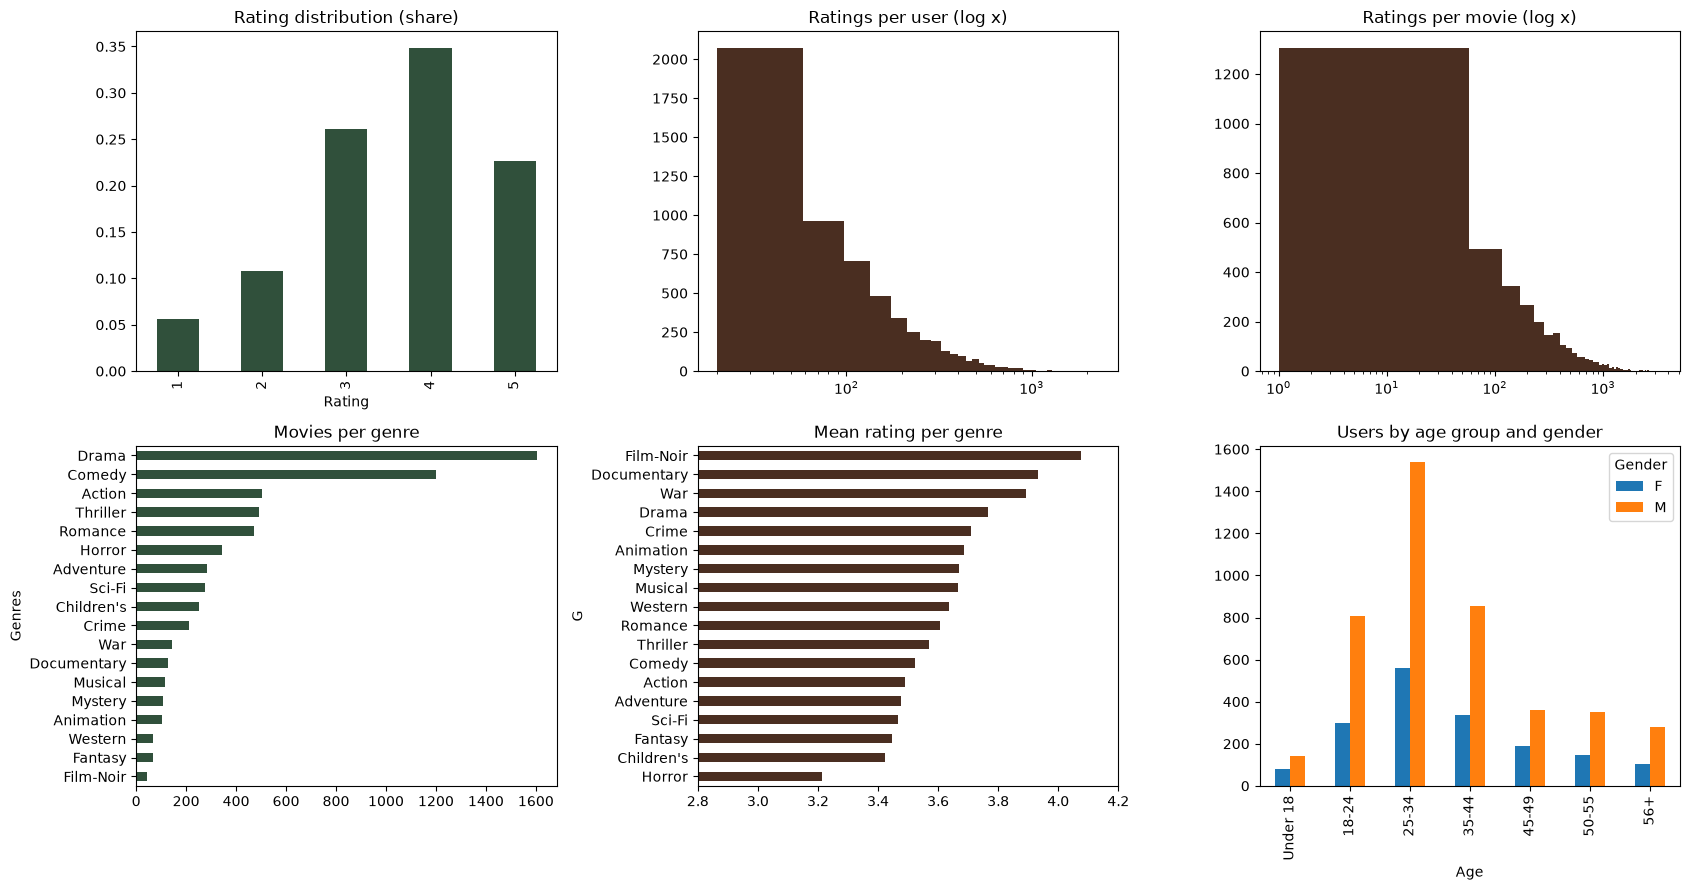

In [58]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
rating_dist.plot.bar(ax=ax[0, 0], color="#30503b", title="Rating distribution (share)")
ax[0, 1].hist(per_user, bins=60, color="#4a2e21"); ax[0, 1].set_xscale("log")
ax[0, 1].set_title("Ratings per user (log x)")
ax[0, 2].hist(per_movie, bins=60, color="#4a2e21"); ax[0, 2].set_xscale("log")
ax[0, 2].set_title("Ratings per movie (log x)")
genre_counts.sort_values().plot.barh(ax=ax[1, 0], color="#30503b", title="Movies per genre")
genre_mean["mean"].plot.barh(ax=ax[1, 1], color="#4a2e21", title="Mean rating per genre")
ax[1, 1].set_xlim(2.8, 4.2)
users.groupby(["Age", "Gender"]).size().unstack().rename(index=AGE_GROUPS).plot.bar(
    ax=ax[1, 2], title="Users by age group and gender")
plt.tight_layout()
plt.show()

In [59]:
print("Missing values  ratings:", int(ratings.isna().sum().sum()), "| users:", int(users.isna().sum().sum()),
      "| movies:", int(movies.isna().sum().sum()))

Missing values  ratings: 0 | users: 0 | movies: 0


In [60]:
n0 = len(ratings)
ratings = ratings.drop_duplicates(["UserID", "MovieID"], keep="last")
print(f"Duplicate (user, movie) ratings removed: {n0 - len(ratings)}")
print(f"Duplicate UserIDs: {users.UserID.duplicated().sum()} | duplicate MovieIDs: {movies.MovieID.duplicated().sum()} "
      f"| duplicate titles: {movies.Title.duplicated().sum()}")
users = users.drop_duplicates("UserID"); movies = movies.drop_duplicates("MovieID")

Duplicate (user, movie) ratings removed: 0
Duplicate UserIDs: 0 | duplicate MovieIDs: 0 | duplicate titles: 0


In [61]:
bad = ~ratings.Rating.between(1, 5)
print(f"Ratings outside 1-5 (removed): {int(bad.sum())}")
ratings = ratings[~bad]
orphans = ~(ratings.UserID.isin(users.UserID) & ratings.MovieID.isin(movies.MovieID))
print(f"Ratings referencing unknown user/movie (removed): {int(orphans.sum())}")
ratings = ratings[~orphans].reset_index(drop=True)

Ratings outside 1-5 (removed): 0
Ratings referencing unknown user/movie (removed): 0


In [62]:
bad_occ = ~users.Occupation.isin(OCCUPATIONS.keys()); bad_age = ~users.Age.isin(AGE_GROUPS.keys())
print(f"Invalid occupation codes: {int(bad_occ.sum())} | invalid age codes: {int(bad_age.sum())} | "
      f"invalid gender values: {int((~users.Gender.isin(['M', 'F'])).sum())}")
users.loc[bad_occ, "Occupation"] = 0

Invalid occupation codes: 0 | invalid age codes: 0 | invalid gender values: 0


In [63]:
zip5 = users.Zip.astype(str).str.extract(r"(\d{5})")[0]
users["Region"] = zip5.str[0].astype(float).fillna(10).astype(int)
print(f"Zip codes without a valid 5-digit prefix (-> region 'unknown'): {int(zip5.isna().sum())}")

Zip codes without a valid 5-digit prefix (-> region 'unknown'): 0


In [64]:
def parse_title(t):
    t = str(t).strip()
    m = re.search(r"\((\d{4})\)\s*$", t)
    year = float(m.group(1)) if m else np.nan
    base = re.sub(r"\s*\(\d{4}\)\s*$", "", t)
    main = re.sub(r"\s*\(.*?\)", "", base).strip()
    m2 = re.match(r"^(.*), (The|A|An)$", main)
    if m2:
        main = f"{m2.group(2)} {m2.group(1)}"
    return pd.Series({"TitleClean": main, "Year": year})


movies = pd.concat([movies, movies.Title.apply(parse_title)], axis=1)
print(f"Movies without a parseable year: {int(movies.Year.isna().sum())} (filled with median year)")
movies["Year"] = movies.Year.fillna(movies.Year.median())
print(f"Release years span {int(movies.Year.min())}-{int(movies.Year.max())}")

Movies without a parseable year: 0 (filled with median year)
Release years span 1919-2000


In [65]:
movies["GenreList"] = movies.Genres.str.split("|").apply(lambda g: [x.strip() for x in g if x.strip() in KNOWN_GENRES])
unknown = set(movies.Genres.str.split("|").explode().str.strip()) - set(KNOWN_GENRES)
print(f"Genre labels outside the official 18: {unknown or 'none'} | movies left with zero genres: "
      f"{int((movies.GenreList.str.len() == 0).sum())}")

Genre labels outside the official 18: none | movies left with zero genres: 0


In [67]:
cnt = ratings.groupby("UserID").size()
q1, q3 = cnt.quantile([.25, .75]); fence = q3 + 1.5 * (q3 - q1)
print(f"Clean ratings: {len(ratings)}")


Clean ratings: 1000209


In [68]:
train_val, test = train_test_split(ratings, test_size=0.10, random_state=SEED)
train, val = train_test_split(train_val, test_size=0.1111, random_state=SEED)  # ~80/10/10
train, val, test = train.copy(), val.copy(), test.copy()
print(f"Split (random, 80/10/10): train={len(train)}, val={len(val)}, test={len(test)}")

Split (random, 80/10/10): train=800177, val=100011, test=100021


In [69]:
users = users.sort_values("UserID").reset_index(drop=True)
movies = movies.sort_values("MovieID").reset_index(drop=True)
uid2idx = {u: i for i, u in enumerate(users.UserID)}
mid2idx = {m: i for i, m in enumerate(movies.MovieID)}
n_users, n_movies = len(users), len(movies)
for df in (train, val, test):
    df["u"] = df.UserID.map(uid2idx).astype(int)
    df["m"] = df.MovieID.map(mid2idx).astype(int)

gmean = float(train.Rating.mean())
u_sum = np.bincount(train.u, weights=train.Rating, minlength=n_users); u_cnt = np.bincount(train.u, minlength=n_users)
m_sum = np.bincount(train.m, weights=train.Rating, minlength=n_movies); m_cnt = np.bincount(train.m, minlength=n_movies)

In [72]:
def add_mean_features(df, is_train):
    r = df.Rating.values
    own = r if is_train else 0.0
    sub = 1 if is_train else 0
    df["user_mean"] = (u_sum[df.u] - own + SHRINK_K * gmean) / (u_cnt[df.u] - sub + SHRINK_K)
    df["movie_mean"] = (m_sum[df.m] - own + SHRINK_K * gmean) / (m_cnt[df.m] - sub + SHRINK_K)


add_mean_features(train, True); add_mean_features(val, False); add_mean_features(test, False)

In [71]:
user_tab = pd.DataFrame({
    "gender_M": (users.Gender == "M").astype(float),
    "age": users.Age.astype(float),
    "user_cnt_log": np.log1p(u_cnt),
})
user_cat = np.stack([users.Occupation.values, users.Region.values], axis=1).astype(np.int64)

In [73]:
mlb = MultiLabelBinarizer(classes=KNOWN_GENRES)
genre_mat = mlb.fit_transform(movies.GenreList).astype(np.float32)

In [74]:
tfidf = TfidfVectorizer(lowercase=True, stop_words="english", min_df=2, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
title_tfidf = tfidf.fit_transform(movies.TitleClean)
n_comp = int(min(N_SVD, title_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
title_svd = svd.fit_transform(title_tfidf)

In [75]:
movie_tab = pd.DataFrame({"year": movies.Year.values, "movie_cnt_log": np.log1p(m_cnt)})
for i in range(n_comp):
    movie_tab[f"svd_{i}"] = title_svd[:, i]

In [76]:
user_num_cols, movie_num_cols = ["age", "user_cnt_log"], list(movie_tab.columns)

In [77]:
user_scaler = StandardScaler().fit(user_tab.iloc[train.u.values][user_num_cols])
movie_scaler = StandardScaler().fit(movie_tab.iloc[train.m.values][movie_num_cols])
stat_scaler = StandardScaler().fit(train[["user_mean", "movie_mean"]])

In [78]:
user_num = np.hstack([user_scaler.transform(user_tab[user_num_cols]), user_tab[["gender_M"]].values]).astype(np.float32)
movie_num = np.hstack([movie_scaler.transform(movie_tab[movie_num_cols]), genre_mat]).astype(np.float32)
print(f"Per-user numeric features: {user_num.shape[1]} | per-movie numeric features: {movie_num.shape[1]}")

Per-user numeric features: 3 | per-movie numeric features: 40


In [79]:
ohe = OneHotEncoder(categories=[list(range(21)), list(range(11))], sparse_output=False, handle_unknown="ignore").fit(user_cat)

In [80]:
def tabular_matrix(df):
    u, m = df.u.values, df.m.values
    return np.hstack([user_num[u], movie_num[m], ohe.transform(user_cat[u]),
                      stat_scaler.transform(df[["user_mean", "movie_mean"]])]).astype(np.float32)


X_tr, X_va, X_te = tabular_matrix(train), tabular_matrix(val), tabular_matrix(test)
y_tr, y_va, y_te = train.Rating.values.astype(np.float32), val.Rating.values.astype(np.float32), test.Rating.values.astype(np.float32)
print(f"Tabular design matrices: train {X_tr.shape}, val {X_va.shape}, test {X_te.shape}")

Tabular design matrices: train (800177, 77), val (100011, 77), test (100021, 77)


In [81]:
results = []

In [82]:
def evaluate(y, p):
    p = np.clip(p, 1, 5)
    return {"RMSE": float(np.sqrt(mean_squared_error(y, p))), "MAE": float(mean_absolute_error(y, p)),
            "R2": float(r2_score(y, p))}


def record(name, family, p_val, p_test, seconds, extra=None):
    mv, mt = evaluate(y_va, p_val), evaluate(y_te, p_test)
    results.append({"model": name, "family": family, "val_RMSE": mv["RMSE"], "val_MAE": mv["MAE"], "val_R2": mv["R2"],
                    "test_RMSE": mt["RMSE"], "test_MAE": mt["MAE"], "test_R2": mt["R2"], "train_sec": seconds,
                    **(extra or {})})
    print(f"  -> {name:<42} val RMSE {mv['RMSE']:.4f} | val MAE {mv['MAE']:.4f} | {seconds:.0f}s")

In [83]:
print("\n[Baselines]")
record("Global mean", "baseline", np.full(len(val), gmean), np.full(len(test), gmean), 0)
bias_pred = lambda df: gmean + (df.user_mean - gmean) + (df.movie_mean - gmean)
record("User mean + movie mean (additive)", "baseline", bias_pred(val).values, bias_pred(test).values, 0)


[Baselines]
  -> Global mean                                val RMSE 1.1171 | val MAE 0.9342 | 0s
  -> User mean + movie mean (additive)          val RMSE 0.9298 | val MAE 0.7303 | 0s


In [84]:
print("\n[Ridge regression on engineered features]")
for alpha in (1.0, 10.0, 100.0):
    t0 = time.time(); r = Ridge(alpha=alpha).fit(X_tr, y_tr)
    record(f"Ridge (alpha={alpha:g})", "linear", r.predict(X_va), r.predict(X_te), time.time() - t0)


[Ridge regression on engineered features]
  -> Ridge (alpha=1)                            val RMSE 0.9207 | val MAE 0.7295 | 0s
  -> Ridge (alpha=10)                           val RMSE 0.9207 | val MAE 0.7295 | 0s
  -> Ridge (alpha=100)                          val RMSE 0.9207 | val MAE 0.7295 | 0s


In [85]:
print("\n[Histogram gradient boosting on engineered features]")
for cfg in ({"learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300},
            {"learning_rate": 0.05, "max_leaf_nodes": 63, "max_iter": 500}):
    t0 = time.time()
    g = HistGradientBoostingRegressor(early_stopping=True, n_iter_no_change=15, random_state=SEED, **cfg).fit(X_tr, y_tr)
    record(f"HistGB (lr={cfg['learning_rate']}, leaves={cfg['max_leaf_nodes']})", "gbm",
           g.predict(X_va), g.predict(X_te), time.time() - t0, {"iters": g.n_iter_})


[Histogram gradient boosting on engineered features]
  -> HistGB (lr=0.1, leaves=31)                 val RMSE 0.9186 | val MAE 0.7295 | 19s
  -> HistGB (lr=0.05, leaves=63)                val RMSE 0.9207 | val MAE 0.7314 | 41s


In [86]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim):
        super().__init__()
        self.user_emb, self.movie_emb = nn.Embedding(n_users, emb_dim), nn.Embedding(n_movies, emb_dim)
        self.user_bias, self.movie_bias = nn.Embedding(n_users, 1), nn.Embedding(n_movies, 1)
        self.register_buffer("global_mean", torch.tensor(gmean))
        for e in (self.user_emb, self.movie_emb):
            nn.init.normal_(e.weight, std=0.05)
        for e in (self.user_bias, self.movie_bias):
            nn.init.zeros_(e.weight)

    def forward(self, u, m):
        dot = (self.user_emb(u) * self.movie_emb(m)).sum(1)
        return self.global_mean + self.user_bias(u).squeeze(-1) + self.movie_bias(m).squeeze(-1) + dot

In [87]:
class HybridRecommender(nn.Module):
    def __init__(self, n_users, n_movies, n_user_num, n_movie_num, emb_dim=32, hidden=128, dropout=0.2,
                 n_occ=21, n_reg=11):
        super().__init__()
        self.register_buffer("user_cat", torch.zeros(n_users, 2, dtype=torch.long))
        self.register_buffer("user_num", torch.zeros(n_users, n_user_num))
        self.register_buffer("movie_num", torch.zeros(n_movies, n_movie_num))
        self.register_buffer("global_mean", torch.tensor(0.0))
        self.user_emb, self.movie_emb = nn.Embedding(n_users, emb_dim), nn.Embedding(n_movies, emb_dim)
        self.user_bias, self.movie_bias = nn.Embedding(n_users, 1), nn.Embedding(n_movies, 1)
        self.occ_emb, self.reg_emb = nn.Embedding(n_occ, 8), nn.Embedding(n_reg, 4)
        in_dim = 2 * emb_dim + 8 + 4 + n_user_num + n_movie_num
        self.mlp = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden // 2, 1))
        for e in (self.user_emb, self.movie_emb, self.occ_emb, self.reg_emb):
            nn.init.normal_(e.weight, std=0.05)
        for e in (self.user_bias, self.movie_bias):
            nn.init.zeros_(e.weight)

    def forward(self, u, m):
        ue, me = self.user_emb(u), self.movie_emb(m)
        cat = self.user_cat[u]
        x = torch.cat([ue, me, self.occ_emb(cat[:, 0]), self.reg_emb(cat[:, 1]), self.user_num[u], self.movie_num[m]], 1)
        return (self.global_mean + self.user_bias(u).squeeze(-1) + self.movie_bias(m).squeeze(-1)
                + (ue * me).sum(1) + self.mlp(x).squeeze(-1))

In [88]:
tu, tm, ty = (torch.tensor(train.u.values, device=DEVICE), torch.tensor(train.m.values, device=DEVICE),
              torch.tensor(y_tr, device=DEVICE))
vu, vm = torch.tensor(val.u.values, device=DEVICE), torch.tensor(val.m.values, device=DEVICE)
eu, em = torch.tensor(test.u.values, device=DEVICE), torch.tensor(test.m.values, device=DEVICE)

In [89]:
@torch.no_grad()
def predict_nn(model, u, m, bs=65536):
    model.eval()
    return torch.cat([model(u[i:i + bs], m[i:i + bs]) for i in range(0, len(u), bs)]).clamp(1, 5).cpu().numpy()

In [90]:
def fit_nn(model, name, lr, wd):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_rmse, best_state, best_ep, bad, hist = 1e9, None, 0, 0, []
    t0 = time.time()
    for ep in range(1, NN_EPOCHS + 1):
        model.train()
        perm = torch.randperm(len(tu), device=DEVICE)
        tot = 0.0
        for i in range(0, len(perm), NN_BATCH):
            idx = perm[i:i + NN_BATCH]
            loss = F.mse_loss(model(tu[idx], tm[idx]), ty[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        v_rmse = float(np.sqrt(mean_squared_error(y_va, predict_nn(model, vu, vm))))
        hist.append((np.sqrt(tot / len(perm)), v_rmse))
        print(f"    epoch {ep:02d}  train RMSE {hist[-1][0]:.4f}  val RMSE {v_rmse:.4f}")
        if v_rmse < best_rmse - 1e-4:
            best_rmse, best_state, best_ep, bad = v_rmse, copy.deepcopy(model.state_dict()), ep, 0
        else:
            bad += 1
            if bad >= NN_PATIENCE:
                print(f"    early stop (best epoch {best_ep})"); break
    model.load_state_dict(best_state)
    record(name, "pytorch", predict_nn(model, vu, vm), predict_nn(model, eu, em), time.time() - t0,
           {"best_epoch": best_ep})
    return hist

In [91]:
def make_hybrid(emb, hidden, drop):
    m = HybridRecommender(n_users, n_movies, user_num.shape[1], movie_num.shape[1], emb, hidden, drop)
    m.user_cat.copy_(torch.tensor(user_cat)); m.user_num.copy_(torch.tensor(user_num))
    m.movie_num.copy_(torch.tensor(movie_num)); m.global_mean.fill_(gmean)
    return m

In [93]:
nn_runs, histories = {}, {}
mf_cfgs = [dict(emb=32, lr=3e-3, wd=0.05), dict(emb=64, lr=3e-3, wd=0.2)]
hy_cfgs = [dict(emb=32, hidden=128, drop=0.2, lr=2e-3, wd=0.05),
           dict(emb=64, hidden=256, drop=0.3, lr=2e-3, wd=0.1),
           dict(emb=32, hidden=128, drop=0.3, lr=2e-3, wd=0.2)]

In [94]:
for c in mf_cfgs:
    name = f"MF (emb={c['emb']}, wd={c['wd']})"
    print(f"\n  Training {name}")
    mdl = MatrixFactorization(n_users, n_movies, c["emb"])
    histories[name] = fit_nn(mdl, name, c["lr"], c["wd"]); nn_runs[name] = (mdl, c, "MatrixFactorization")


  Training MF (emb=32, wd=0.05)
    epoch 01  train RMSE 1.0379  val RMSE 0.9599
    epoch 02  train RMSE 0.8993  val RMSE 0.8869
    epoch 03  train RMSE 0.8337  val RMSE 0.8701
    epoch 04  train RMSE 0.7897  val RMSE 0.8670
    epoch 05  train RMSE 0.7572  val RMSE 0.8706
    epoch 06  train RMSE 0.7332  val RMSE 0.8757
    epoch 07  train RMSE 0.7154  val RMSE 0.8814
    epoch 08  train RMSE 0.7018  val RMSE 0.8865
    early stop (best epoch 4)
  -> MF (emb=32, wd=0.05)                       val RMSE 0.8670 | val MAE 0.6787 | 2s

  Training MF (emb=64, wd=0.2)
    epoch 01  train RMSE 1.0352  val RMSE 0.9458
    epoch 02  train RMSE 0.8820  val RMSE 0.8803
    epoch 03  train RMSE 0.8086  val RMSE 0.8659
    epoch 04  train RMSE 0.7515  val RMSE 0.8646
    epoch 05  train RMSE 0.7070  val RMSE 0.8693
    epoch 06  train RMSE 0.6741  val RMSE 0.8747
    epoch 07  train RMSE 0.6497  val RMSE 0.8801
    epoch 08  train RMSE 0.6313  val RMSE 0.8853
    early stop (best epoch 4)
  -> 

In [95]:
for c in hy_cfgs:
    name = f"Hybrid NN (emb={c['emb']}, h={c['hidden']}, drop={c['drop']}, wd={c['wd']})"
    print(f"\n  Training {name}")
    mdl = make_hybrid(c["emb"], c["hidden"], c["drop"])
    histories[name] = fit_nn(mdl, name, c["lr"], c["wd"]); nn_runs[name] = (mdl, c, "HybridRecommender")


  Training Hybrid NN (emb=32, h=128, drop=0.2, wd=0.05)
    epoch 01  train RMSE 0.9469  val RMSE 0.9036
    epoch 02  train RMSE 0.8950  val RMSE 0.8916
    epoch 03  train RMSE 0.8758  val RMSE 0.8783
    epoch 04  train RMSE 0.8579  val RMSE 0.8699
    epoch 05  train RMSE 0.8418  val RMSE 0.8632
    epoch 06  train RMSE 0.8275  val RMSE 0.8599
    epoch 07  train RMSE 0.8146  val RMSE 0.8580
    epoch 08  train RMSE 0.8023  val RMSE 0.8576
    epoch 09  train RMSE 0.7901  val RMSE 0.8568
    epoch 10  train RMSE 0.7785  val RMSE 0.8590
    epoch 11  train RMSE 0.7673  val RMSE 0.8598
    epoch 12  train RMSE 0.7568  val RMSE 0.8618
    epoch 13  train RMSE 0.7467  val RMSE 0.8658
    early stop (best epoch 9)
  -> Hybrid NN (emb=32, h=128, drop=0.2, wd=0.05) val RMSE 0.8568 | val MAE 0.6690 | 5s

  Training Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)
    epoch 01  train RMSE 0.9384  val RMSE 0.9010
    epoch 02  train RMSE 0.8874  val RMSE 0.8829
    epoch 03  train RMSE 0.8589  v

In [96]:
res = pd.DataFrame(results).sort_values("val_RMSE").reset_index(drop=True)
res.to_csv(f"{ART_DIR}/experiment_results.csv", index=False)
print(res[["model", "val_RMSE", "val_MAE", "val_R2", "test_RMSE", "test_MAE", "test_R2", "train_sec"]]
      .round(4).to_string(index=False))

                                       model  val_RMSE  val_MAE  val_R2  test_RMSE  test_MAE  test_R2  train_sec
 Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)    0.8529   0.6671  0.4170     0.8546    0.6679   0.4140     3.9570
 Hybrid NN (emb=32, h=128, drop=0.3, wd=0.2)    0.8537   0.6680  0.4160     0.8553    0.6693   0.4131     5.1989
 Hybrid NN (emb=32, h=128, drop=0.3, wd=0.2)    0.8538   0.6676  0.4158     0.8546    0.6682   0.4140     5.3370
 Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)    0.8549   0.6707  0.4144     0.8566    0.6718   0.4114     3.7110
Hybrid NN (emb=32, h=128, drop=0.2, wd=0.05)    0.8563   0.6695  0.4124     0.8580    0.6711   0.4095     4.3036
Hybrid NN (emb=32, h=128, drop=0.2, wd=0.05)    0.8568   0.6690  0.4117     0.8574    0.6700   0.4103     4.8720
                         MF (emb=64, wd=0.2)    0.8646   0.6781  0.4009     0.8663    0.6797   0.3979     1.6976
                         MF (emb=64, wd=0.2)    0.8667   0.6801  0.3981     0.8672    0.6805   0

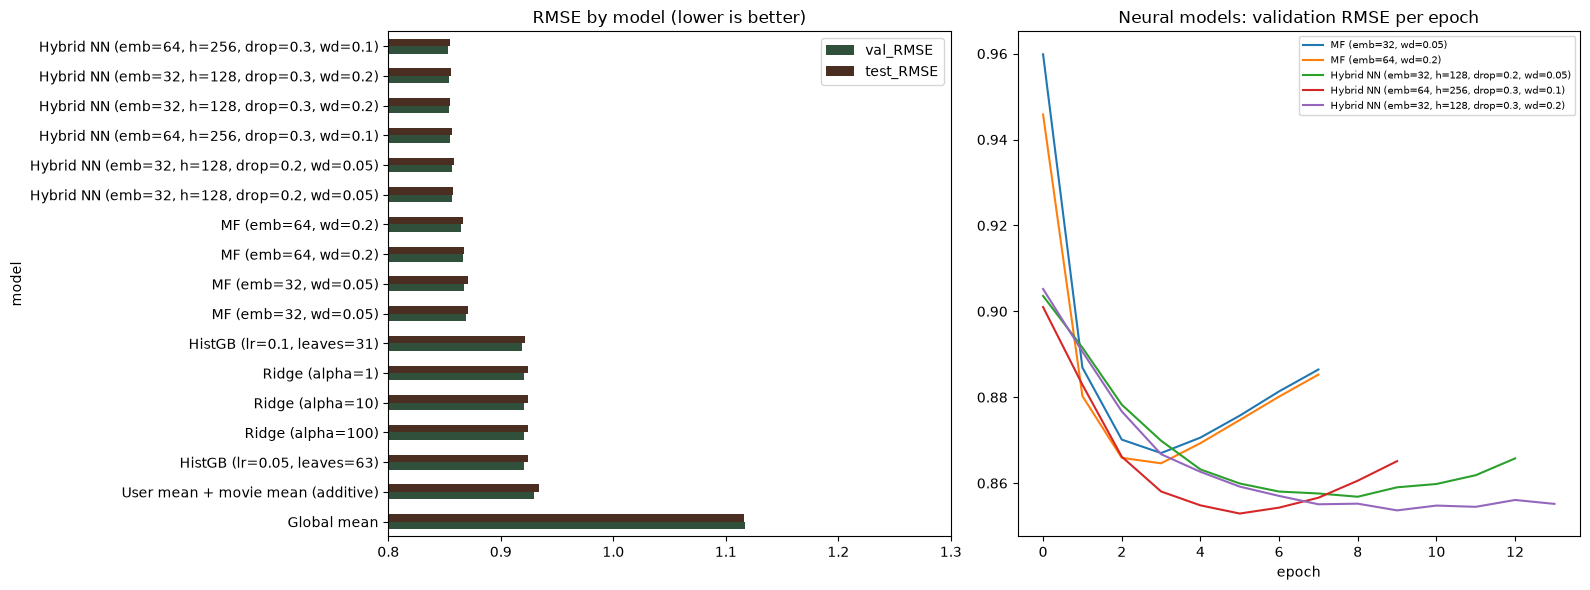

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
res.sort_values("val_RMSE", ascending=False).plot.barh(x="model", y=["val_RMSE", "test_RMSE"], ax=ax[0],
                                                       color=["#30503b", "#4a2e21"])
ax[0].set_xlim(0.8, 1.3); ax[0].set_title("RMSE by model (lower is better)")
for name, h in histories.items():
    ax[1].plot([v for _, v in h], label=name)
ax[1].set_title("Neural models: validation RMSE per epoch"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [99]:
best_all = res.iloc[0]
print(f"\nBest overall on validation: {best_all.model}")


Best overall on validation: Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)


In [100]:
nn_res = res[res.family == "pytorch"]
best_name = nn_res.iloc[0].model
best_model, best_cfg, best_cls = nn_runs[best_name]
print(f"Deployed model: {best_name}")

Deployed model: Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)


In [102]:
final = res[res.model == best_name].iloc[0]
print(f"\nFINAL TEST RESULT ({best_name}): RMSE {final.test_RMSE:.4f} | MAE {final.test_MAE:.4f} | R2 {final.test_R2:.4f}")


FINAL TEST RESULT (Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)): RMSE 0.8546 | MAE 0.6679 | R2 0.4140


In [103]:
if best_cls != "HybridRecommender":
    best_name = nn_res[nn_res.model.str.startswith("Hybrid")].iloc[0].model
    best_model, best_cfg, best_cls = nn_runs[best_name]
    final = res[res.model == best_name].iloc[0]
    print(f"(Matrix factorisation ranked first; deploying best Hybrid instead: {best_name})")

In [104]:
best_model.cpu().eval()
torch.save(best_model.state_dict(), f"{ART_DIR}/model.pt")
config = {"model_name": best_name, "architecture": best_cls, "n_users": n_users, "n_movies": n_movies,
          "n_user_num": int(user_num.shape[1]), "n_movie_num": int(movie_num.shape[1]),
          "emb_dim": best_cfg["emb"], "hidden": best_cfg["hidden"], "dropout": best_cfg["drop"],
          "global_mean": gmean, "metrics": {k: float(final[k]) for k in ("val_RMSE", "test_RMSE", "test_MAE", "test_R2")}}
json.dump(config, open(f"{ART_DIR}/model_config.json", "w"), indent=2)
joblib.dump({"genre_binarizer": mlb, "title_tfidf": tfidf, "title_svd": svd, "user_scaler": user_scaler,
             "movie_scaler": movie_scaler, "stat_scaler": stat_scaler, "onehot_occ_region": ohe,
             "uid2idx": uid2idx, "mid2idx": mid2idx}, f"{ART_DIR}/preprocessing.joblib")

['artifacts/preprocessing.joblib']

In [105]:
all_cnt = ratings.groupby("UserID").size()
users_out = users.assign(AgeGroup=users.Age.map(AGE_GROUPS), OccupationName=users.Occupation.map(OCCUPATIONS),
                         n_ratings=users.UserID.map(all_cnt).fillna(0).astype(int), u_idx=np.arange(n_users))
users_out[["UserID", "u_idx", "Gender", "AgeGroup", "OccupationName", "n_ratings"]].to_csv(
    f"{ART_DIR}/users_lookup.csv", index=False)
movies_out = pd.DataFrame({"MovieID": movies.MovieID, "m_idx": np.arange(n_movies), "Title": movies.TitleClean,
                           "Year": movies.Year.astype(int), "Genres": movies.Genres, "train_count": m_cnt,
                           "avg_rating": np.where(m_cnt > 0, m_sum / np.maximum(m_cnt, 1), np.nan)})
movies_out.to_csv(f"{ART_DIR}/movies_lookup.csv", index=False)
ratings[["UserID", "MovieID", "Rating"]].to_csv(f"{ART_DIR}/ratings_clean.csv.gz", index=False)
print("Saved to ./" + ART_DIR + ":", ", ".join(sorted(os.listdir(ART_DIR))))

Saved to ./artifacts: experiment_results.csv, model.pt, model_config.json, movies_lookup.csv, preprocessing.joblib, ratings_clean.csv.gz, users_lookup.csv
